# Neural networks II

We continue to look at more neural network architectures and applications. 

## Convolutional neural networks

Convolutional neural networks (CNNs) are a particular class of neural networks designed to model stationary signals, i.e., signals whose statistical properties remain consistent across space or time. For instance, many images exhibit similar statistical characteristics in different regions. As a result, features learned in one area can often be applied to others. Convolutions provide an efficient way to extract such features. A CNN consists of many different types of convolution layers. 

Let us focus on the 2D case of images and think of an image as an $m \times n$ matrix $I \in \mathbb{R}^{m \times n}$ whose $(m,n)$-th entry contains the intensity of the $(m,n)$ pixel. In practice, one needs three such matrices to represent a color image (one matrix for the intensity of red, one for green, and one for blue if using the <a href="https://en.wikipedia.org/wiki/RGB_color_model" target="_blank">RGB representation</a>). Here, we will focus on the case of one matrix, but everything discussed in this chapter applies to color images as well by applying the same process to each matrix/channel. Let $F \in \mathbb{R}^{k \times l}$ be a $k \times l$ matrix that we will call a *convolution filter*. The result of convolving the image $I$ with $F$, denoted $I \star F$ is a new matrix $I' \in \mathbb{R}^{(m-k+1) \times (n-l+1)}$ whose $(i,j)$-th entry is given by 

$$
I'(i,j) = (I \star F)(i,j) = \sum_{r=1}^k \sum_{s=1}^l I(i+r-1, j+s-1) F(r,s).
$$

In other words, the $(i,j)$-th entry of $I \star F$ is obtained by superposing the upper left corner of $F$ on the $(i,j)$ entry of $I$, multiplying the two matrices together entrywise, and adding the resulting entries. To obtain the whole image, this process is repeated by moving the filter on the original image.

```{figure} images/convolution-img.png
---
width: 600 px
---
Illustration of the convolution of an $8 \times 8$ image with a $3 \times 3$ filter. 
```

In the field of image processing, different filters are known to extract various features of an image. 

```{figure} images/convolution-kernel.png
---
width: 500 px
---
Convolution filters applied to an image.
```

For example, observe how the first filter in the above figure 

$$
\begin{pmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{pmatrix}
$$

compares the center pixel to its neighbors. Regions where pixel colors change rapidely get a larger value under this filter. As a result, the filter tends to pick up the edges between object. Other filters can extract all kind of features from an image. 

If you are seeing CNNs for the first time, you may wonder: what filters should I use in my models? In the past, one would have studied the properties of convolution filters or consulted experts in the area to make that decision. These days, the point of machine learning is that we can let the computer *learn* the filters that work best. In our models, we have to specify the number of filters we want to use in each layer, but each filter has trainable parameters that we can optimize to get the best results possible. 

Two operations are often performed on convolution layers: padding and stride.

### Padding 
In practice, it is often convenient to add some *padding* to an image (i.e., add zeros around it) to preserve (or approximately preserve) the image dimension, and to better extract information near the borders. 

```{figure} images/convo-anim.gif
---
width: 300 px
---
Convolution with padding. (Credits: Divyanshu Mishra, towardsdatascience.com.)
```

Suppose we add $p_h$ rows above and below the image, and $p_w$ columns on the left and right of the original image. The new padded image now has dimension $(m+2p_h) \times (n + 2 p_w)$. Convolving with a $k \times l$ filter yields an image of dimension 

$$
(m + 2p_h - k + 1) \times (n + 2 p_w - l + 1).
$$ 

For instance, if the original image is $100 \times 100$ pixels and we use a $9 \times 9$ filter with $p_h = p_w = 4$ padding, then 

$$
m + 2 p_h - k + 1 = n + 2 p_w -l + 1 = 100 + 2 \times 4 - 9 + 1 = 100.  
$$

Thus, the resulting convoluted image still has dimension $100 \times 100$. 

### Stride

Another technique that can be used to downsample an image and summarize it is to move the filter by more than one unit at a time in either direction. This can also help reduce the computational cost of performing the convolution and therefore speed up calculations. We denote the horizontal and vertical *stride* by $s_h$ and $s_w$ respectively, i.e., $s_h$ is the number of pixels by which we move the filter in the horizontal direction, and $s_w$ in the vertical direction. If a stride is included, the resulting image dimension becomes 

$$
\left(\left\lfloor \frac{m + 2 p_h - k}{s_h}  \right\rfloor + 1\right) \times \left(\left\lfloor \frac{n + 2 p_w - k}{s_w}  \right\rfloor + 1\right), 
$$

where $\lfloor x \rfloor$ denotes the <a href="https://en.wikipedia.org/wiki/Floor_and_ceiling_functions" target="_blank">floor function</a>.

## Pooling

A different way to summarize image information and create more robust and invariant features is called *pooling*. For example, *max pooling* replaces the pixel values in a region by their maximum, while *average pooling* replaces them by their average.

```{figure} images/pooling.png
---
width: 400 px
---
Illustration of max and average pooling.
```

In the case of pooling, notice that we typically move the filter in a **non-overlapping** manner, i.e., the stride is equal to the size of the filter. For instance, in the above figure, the $2 \times 2$ pooling filter moves by two units at a time to reduce the $4 \times 4$ image to a $2 \times 2$ image. 

## Convolutions in PyTorch

The <a href="https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html" target="_blank">Conv2d</a> object in PyTorch can be used to create convolution layers. It can take an arbitrary number of input images (*in_channels*) and outputs an arbitrary number of convoluted images (*out_channels*), each with its own filter. For instance, 

nn.Conv2d(1, 10, 3, padding=1)

represents $10$ convolutions with $3 \times 3$ filters (with their own trainable parameters) and padding of $1$ (on both sides). The <a href="https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html" target="_blank">MaxPool2d</a> object can be used to construct max pooling layers. For example, 

nn.MaxPool2d(2, 2)

represents a $2 \times 2$ max pooling layer.

A typical convolutional neural network consists of several layers of convolutions followed by polling, and usually ends with one or more fully connected layers. For instance, the following CNN can be used to identify handwritten digits

```{figure} images/digits.jpeg
---
width: 800 px
---
Convolutional neural network to predict handwritten digits
```

You will construct and train several such networks in the next chapter. 

We conclude this chapter by discussing other important neural network architectures and variants. 

## Autoencoders

An *autoencoder* learns the identity function through a neural network, i.e., its output is the same as its input. However, a small hidden layer is used to *compress* the information and learn some features from the data. 

```{figure} images/autoencoder.png
---
width: 300 px
---
Illustration of an autoencoder with six inputs, three hidden nodes, and six outputs.
```

For example, let us train an autoencoder on the scikit-learn handwritten digits dataset. Instead of training the network directly on the whole dataset, we will use a batch size of 64, as discussed in section {ref}`S-stochastic-gradient-minibatch`. Let us begin by loading the data, normalizing it, and splitting it into a training and testing set.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# ==== PARAMETERS ====
hidden_dim = 32     # number of hidden nodes (this can be changed as needed)
batch_size = 64
epochs = 50
learning_rate = 1e-3

# ==== LOAD DATA ====
digits = load_digits()
X = digits.data  # shape (1797, 64)
X = MinMaxScaler().fit_transform(X)  # scale pixels to [0,1]

# Split into train/test
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, X_test), batch_size=batch_size, shuffle=False)

We can now define our autoencoder model with one hidden layer.

In [3]:
# ==== DEFINE AUTOENCODER ====
class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=32):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),  # since inputs are scaled to [0,1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

To train our autoencoder, remember that we want the output to match the input. This is accomplished in the code below by setting 

loss = criterion(outputs, batch)

to measure the error between the input images and their output after passing through the neural network. Although this is not necessary for this problem, the code below will run on the GPU if one is available on your computer (and you have a GPU-supported version of PyTorch installed). This can considerably speed-up calculations when working with a large number of images. 

In [4]:
# ==== TRAINING ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(input_dim=64, hidden_dim=hidden_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [1/50], Loss: 0.160941
Epoch [2/50], Loss: 0.110209
Epoch [3/50], Loss: 0.079731
Epoch [4/50], Loss: 0.072255
Epoch [5/50], Loss: 0.068475
Epoch [6/50], Loss: 0.064300
Epoch [7/50], Loss: 0.059673
Epoch [8/50], Loss: 0.054943
Epoch [9/50], Loss: 0.050420
Epoch [10/50], Loss: 0.046508
Epoch [11/50], Loss: 0.043244
Epoch [12/50], Loss: 0.040524
Epoch [13/50], Loss: 0.038217
Epoch [14/50], Loss: 0.036214
Epoch [15/50], Loss: 0.034293
Epoch [16/50], Loss: 0.032581
Epoch [17/50], Loss: 0.031076
Epoch [18/50], Loss: 0.029747
Epoch [19/50], Loss: 0.028586
Epoch [20/50], Loss: 0.027478
Epoch [21/50], Loss: 0.026483
Epoch [22/50], Loss: 0.025580
Epoch [23/50], Loss: 0.024746
Epoch [24/50], Loss: 0.023959
Epoch [25/50], Loss: 0.023241
Epoch [26/50], Loss: 0.022551
Epoch [27/50], Loss: 0.021899
Epoch [28/50], Loss: 0.021294
Epoch [29/50], Loss: 0.020695
Epoch [30/50], Loss: 0.020130
Epoch [31/50], Loss: 0.019565
Epoch [32/50], Loss: 0.018985
Epoch [33/50], Loss: 0.018433
Epoch [34/50], Loss

Finally, let us evaluate our model on the testing set to make sure our autoencoder works well (i.e., is able to replicate images via the compressed network).

In [5]:
# ==== EVALUATE ====
model.eval()
with torch.no_grad():
    X_test_recon = model(X_test.to(device)).cpu()

reconstruction_error = torch.mean((X_test - X_test_recon) ** 2).item()
print(f"Test reconstruction MSE: {reconstruction_error:.6f}")

Test reconstruction MSE: 0.012104


Notice that the testing MSE is quite small. It therefore seems like our model is learning well. Let us verify by looking at the output of some actual images in the testing set.

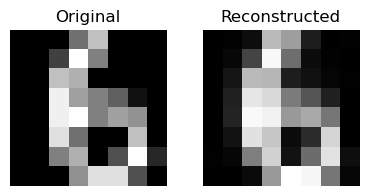

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one sample from the test set
idx = 0
sample = X_test[idx].unsqueeze(0)  # shape (1, 64)

# Pass it through the autoencoder
model.eval()
with torch.no_grad():
    reconstructed = model(sample).numpy().reshape(8, 8)

# Original image (reshape to 8x8)
original = X_test[idx].numpy().reshape(8, 8)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title("Reconstructed")
axes[1].axis('off')

plt.tight_layout()
plt.show()


While they are not identical, the images look very similar. Note that this was accomplished by squeezing the 64 dimensions of the images into 32 dimensions. As an exercise, you may want to play with the number of hidden neurons to see how much the data can be further compressed.

```{admonition} Exercise.

Try different numbers of hidden neurons in the above autoencoder. How small can this number get to still obtain a reasonable error?
```

Once an autoencoder has been trained, we can try to visualize what its different neurons have learned. Recall that the $i$-th neuron in the hidden layer computes an affine combination of its input followed by an activation function:

$$
a^{(2)}_i = f\left(\sum_{j=1}^{d} W_{ij}^{(1)} x_j + b_j^{(1)}\right).
$$

It is natural to ask what input *maximally activates* the neuron. This is not a well-defined problem since the neuron activation can be as large as we want if we keep increasing the size of the input $x$. However, the problem becomes well-defined if we assume the image is normalized to have norm $1$. We therefore want to solve the problem: 

$$
\max_{\substack{x \in \mathbb{R}^d \\ \|x\| = 1}} \sum_{j=1}^{d} W_{ij}^{(1)} x_j + b_j^{(1)}.
$$

Notice that the constant $b_j^{(1)}$ plays no role in maximally activating the neuron. The image $x$ that solves the problem is the same as the one solving: 

$$
\max_{\substack{x \in \mathbb{R}^d \\ \|x\| = 1}} \sum_{j=1}^{d} W_{ij}^{(1)} x_j.
$$


Let $w \in \mathbb{R}^d$ be the vector with entries $w = (W_{i1}^{(1)}, W_{i2}^{(1)}, \dots, W_{id}^{(1)})^T$. By the <a href="https://en.wikipedia.org/wiki/Cauchy%E2%80%93Schwarz_inequality" target="_blank">Cauchy-Schwarz inequality</a>, and using the fact that $\|x\| = 1$, we obtain 

$$
\sum_{j=1}^{d} W_{ij}^{(1)} x_j = \langle w, x\rangle \leq \|w\| \cdot \|x\| = \|w\| = \left(\sum_{j=1}^d (W_{ij}^{(1)})^2\right)^{1/2}.
$$

Moreover, by the equality case in Cauchy--Schwarz, equality is obtained if and only if $w$ and $x$ are linearly dependent, i.e., if $x = \lambda w$ for some $\lambda \in \mathbb{R}$. Since $\|x\|=1$, we must have $\lambda = 1/\|w\|$. Thus $x = w/\|w\|$ and so 

$$
x_j = \frac{W_{ij}^{(1)}}{\left(\sum_{j=1}^d (W_{ij}^{(1)})^2\right)^{1/2}} \qquad (j=1,\dots,d).
$$

Going back to our autoencoder, let us display the images that maximally activate each neuron. 

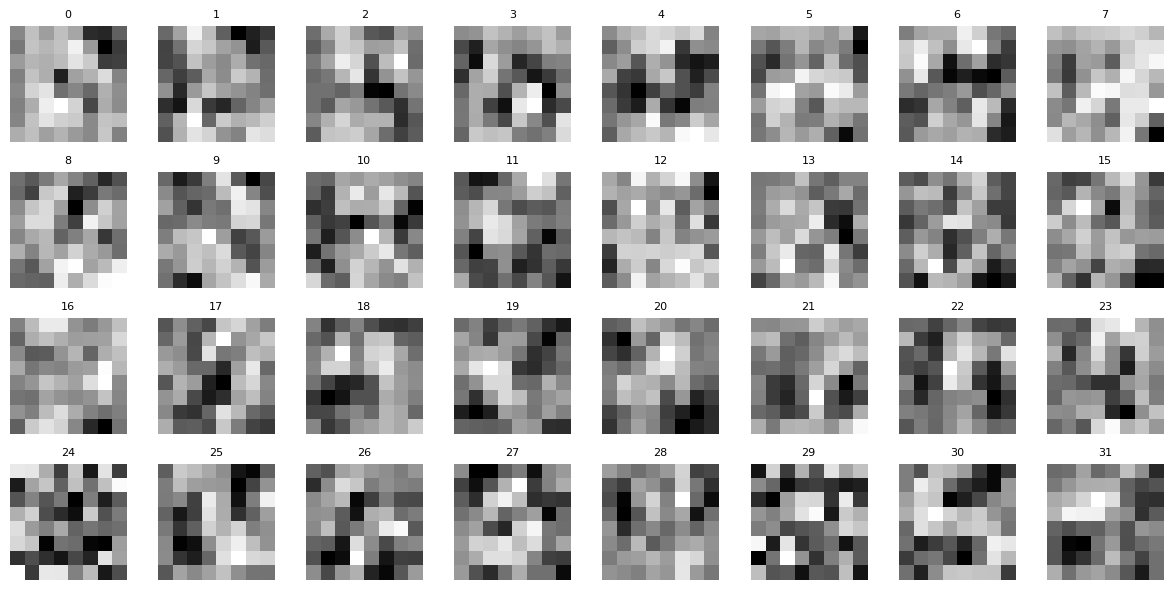

In [10]:
# Extract encoder weight matrix (shape: hidden_dim x 64)
W = model.encoder[0].weight.detach().cpu().numpy()

# Normalize each neuron's weight vector
W_norm = W / np.linalg.norm(W, axis=1, keepdims=True)

# Determine grid size
n_neurons = W_norm.shape[0]
n_rows, n_cols = 4, 8   # for 32 neurons

# Create grid of plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5*n_cols, 1.5*n_rows))

for i in range(n_rows * n_cols):
    ax = axes[i // n_cols, i % n_cols]
    if i < n_neurons:
        ax.imshow(W_norm[i].reshape(8, 8), cmap='gray')
        ax.set_title(f"{i}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()



Notice how the autoencoder seems to learn patterns corresponding to the shape of the different numbers. For a given image, each neuron fires more or less depending on whether or not the pattern it is looking for is present in the image. It is remarkable that images can be compressed in such as way, and be almost perfectly reconstructed!

## Dropouts

So far, the neural networks we looked at were fully connected. This results in a large number of parameters to learn, making training more difficult. Many *sparse* models have been proposed in the literature. A common way to obtain such models is to use *dropouts*. i.e., to randomly ignore (or ``drop out'') some neurons during training. In practice, one often specifies a dropout rate, i.e., a fixed probability $0 \leq p \leq 1$ of ignoring a given node. Neurons are then dropped randomly every time a batch is passed through the network during training. It is common to use a rate between $20\%$ and $50\%$. 

```{figure} images/dropout.png
---
width: 500 px
---
A neural network with dropouts.
```

Using dropouts usually increases the performance of neural networks. This is a technique worth considering when constructing models. PyTorch provides an easy way to drop neurons. One simply has to include a <a href="https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html" target="_blank">nn.Dropout</a> layer. For instance, to drop $50\%$ of the neurons in a given layer, one would include a layer of the form

nn.Dropout(p=0.5)

into the model. 